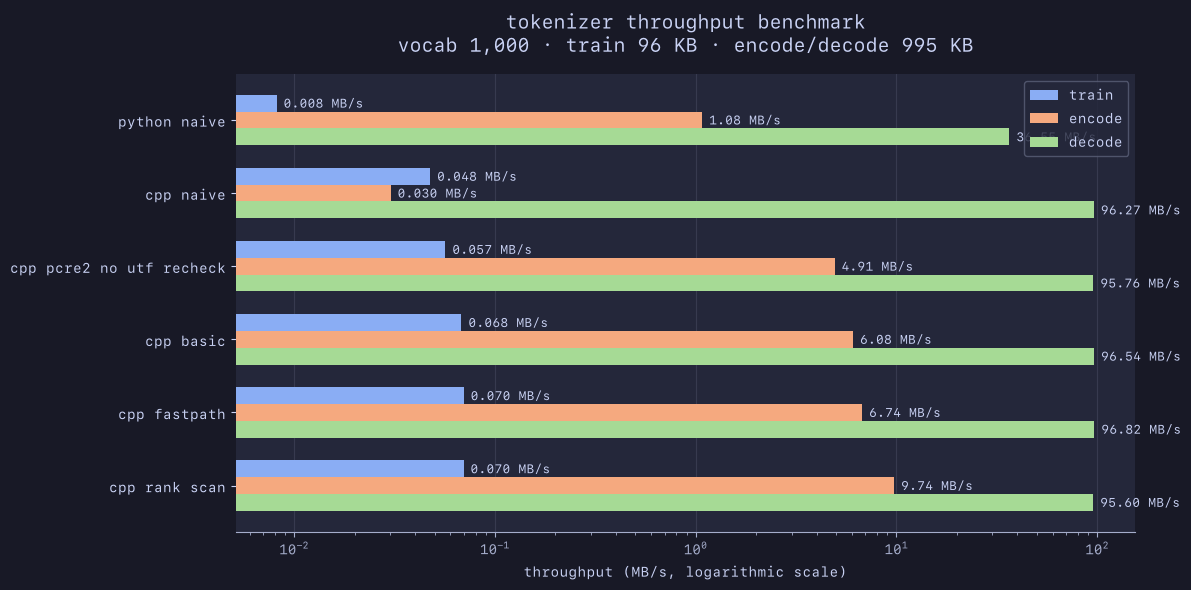

In [3]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

background = "#181926"
panel = "#24273A"
text = "#CAD3F5"
muted = "#A5ADCB"
grid = "#5B6078"

colors = [
    "#8AADF4",  # pastel blue
    "#F5A97F",  # pastel peach
    "#A6DA95",  # pastel green
]

plt.rcParams.update({
    "font.family": "monospace",
    "font.monospace": ["SF Mono", "Menlo", "DejaVu Sans Mono"],
    "figure.facecolor": background,
    "axes.facecolor": panel,
    "axes.edgecolor": muted,
    "axes.labelcolor": text,
    "xtick.color": muted,
    "ytick.color": text,
    "text.color": text,
})


records = [
    json.loads(line)
    for line in Path("benchmarks.jsonl").read_text().splitlines()
    if line.strip()
]

latest = {
    (record["label"], record["operation"]): record
    for record in records
}

operations = ["train", "encode", "decode"]
implementations = list(dict.fromkeys(record["label"] for record in records))

implementations = [
    name
    for name in implementations
    if all((name, operation) in latest for operation in operations)
]


def format_speed(speed):
    if speed >= 1000:
        return f"{speed / 1000:.2f} GB/s"
    if speed < 0.1:
        return f"{speed:.3f} MB/s"
    return f"{speed:.2f} MB/s"


y = np.arange(len(implementations))
height = 0.23

figure, axis = plt.subplots(figsize=(12, 6))

for index, operation in enumerate(operations):
    speeds = [
        latest[(name, operation)]["median_throughput_bytes_per_second"]
        / 1_000_000
        for name in implementations
    ]

    bars = axis.barh(
        y + (index - 1) * height,
        speeds,
        height,
        label=operation,
        color=colors[index],
        edgecolor="none",
    )

    axis.bar_label(
        bars,
        labels=[format_speed(speed) for speed in speeds],
        padding=5,
        fontsize=9,
        color=text,
    )

axis.set_yticks(
    y,
    [name.replace("-", " ") for name in implementations],
)

axis.set_xscale("log")
axis.set_xlabel("throughput (MB/s, logarithmic scale)")
axis.set_title(
    "tokenizer throughput benchmark\n"
    "vocab 1,000 · train 96 KB · encode/decode 995 KB",
    fontsize=14,
    pad=16,
)

axis.invert_yaxis()
axis.grid(axis="x", color=grid, alpha=0.35)
axis.set_axisbelow(True)

axis.legend(
    facecolor=panel,
    edgecolor=grid,
    labelcolor=text,
)

axis.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()